# Exploratory Data Analysis
**Medical Insurance Risk Dataset** — 1,337 records · 24 features · Target: is_high_risk

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings



warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120



df = pd.read_csv("../../data/raw/medical_insurance.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (1337, 25)


,record_date,year,quarter,age,age_group,sex,sex_female,bmi,bmi_category,children,...,region_northeast,region_northwest,region_southeast,region_southwest,charges,monthly_premium_est,charges_per_child,insurance_tier,bmi_age_interaction,high_risk_threshold
0,2024-02-01,2024,1,19,Young Adult (18-25),female,1,27.90,Overweight,0,...,0,0,0,1,16884.92,1407.08,0.00,Platinum,530.10,16657.72
1,2024-12-30,2024,4,18,Young Adult (18-25),male,0,33.77,Obese Class I,1,...,0,0,1,0,1725.55,143.80,1725.55,Bronze,607.86,16657.72
2,2023-05-11,2023,2,28,Adult (26-35),male,0,33.00,Obese Class I,3,...,0,0,1,0,4449.46,370.79,1483.15,Silver,924.00,16657.72
3,2024-07-18,2024,3,33,Adult (26-35),male,0,22.70,Normal Weight,0,...,0,1,0,0,21984.47,1832.04,0.00,Diamond,749.10,16657.72
4,2024-02-05,2024,1,32,Adult (26-35),male,0,28.88,Overweight,0,...,0,1,0,0,3866.86,322.24,0.00,Bronze,924.16,16657.72


## 1. Schema and Nulls

In [5]:
print(df.dtypes)
print("Null counts:")
print(df.isnull().sum())

record_date                str
year                     int64
quarter                  int64
age                      int64
age_group                  str
sex                        str
sex_female               int64
bmi                    float64
bmi_category               str
children                 int64
smoker                     str
smoker_flag              int64
is_high_risk             int64
risk_score             float64
region                     str
region_northeast         int64
region_northwest         int64
region_southeast         int64
region_southwest         int64
charges                float64
monthly_premium_est    float64
charges_per_child      float64
insurance_tier             str
bmi_age_interaction    float64
high_risk_threshold    float64
dtype: object
Null counts:
record_date            0
year                   0
quarter                0
age                    0
age_group              0
sex                    0
sex_female             0
bmi                    

## 2. Target Distribution

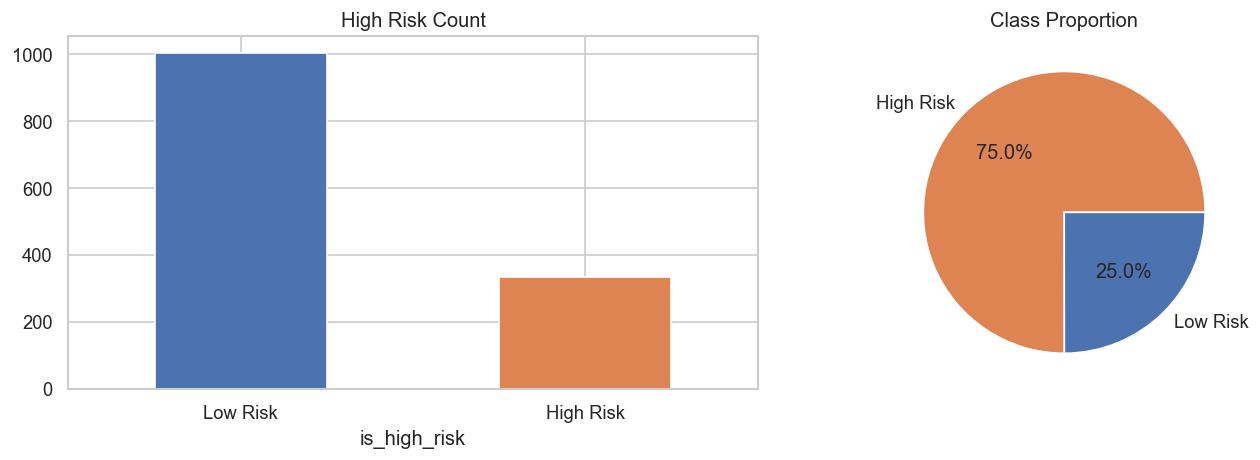

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["is_high_risk"].value_counts().plot(kind="bar", ax=axes[0], color=["#4C72B0","#DD8452"])
axes[0].set_title("High Risk Count")
axes[0].set_xticklabels(["Low Risk","High Risk"], rotation=0)
df["is_high_risk"].value_counts(normalize=True).plot(kind="pie", ax=axes[1], labels=["High Risk","Low Risk"], autopct="%1.1f%%", colors=["#DD8452","#4C72B0"])
axes[1].set_title("Class Proportion")
plt.tight_layout()
plt.savefig("../../artifacts/plots/eda_target_distribution.png", bbox_inches="tight")
plt.show()

## 3. Numeric Distributions

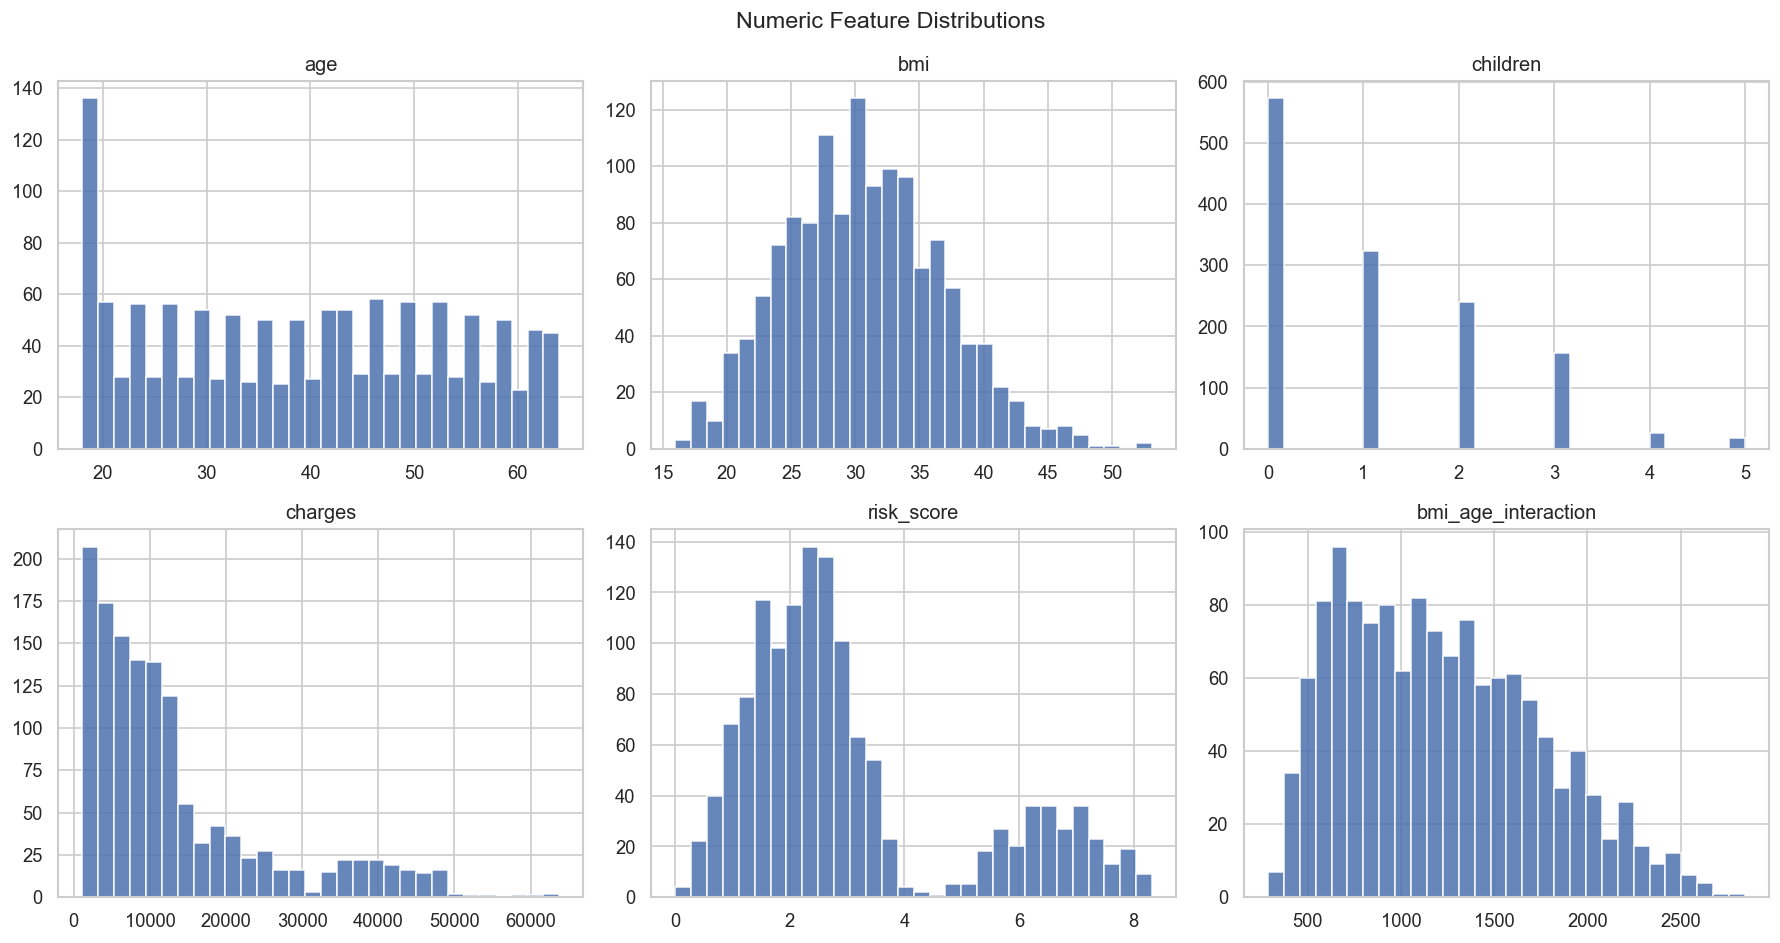

In [8]:
cols = ["age","bmi","children","charges","risk_score","bmi_age_interaction"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(cols):
    axes[i].hist(df[col], bins=30, color="#4C72B0", edgecolor="white", alpha=0.85)
    axes[i].set_title(col)
plt.suptitle("Numeric Feature Distributions", fontsize=14)
plt.tight_layout()
plt.savefig("../../artifacts/plots/eda_numeric_distributions.png", bbox_inches="tight")
plt.show()

## 4. Risk Rate by Categorical Features

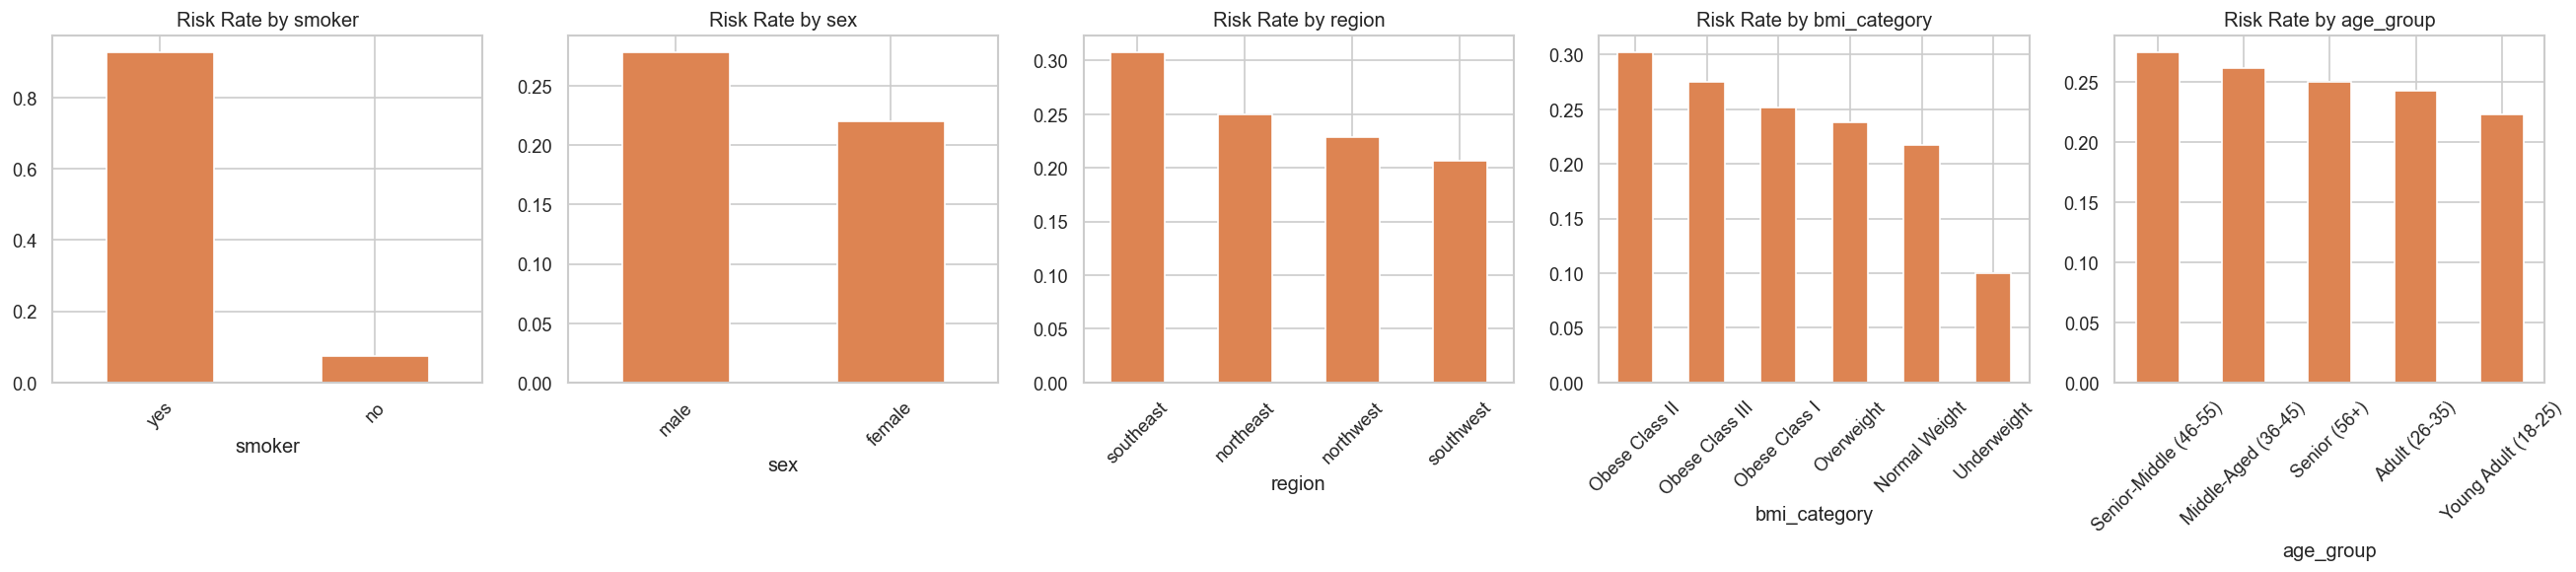

In [9]:
cat_cols = ["smoker","sex","region","bmi_category","age_group"]
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for i, col in enumerate(cat_cols):
    r = df.groupby(col)["is_high_risk"].mean().sort_values(ascending=False)
    r.plot(kind="bar", ax=axes[i], color="#DD8452", edgecolor="white")
    axes[i].set_title(f"Risk Rate by {col}")
    axes[i].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("../../artifacts/plots/eda_risk_by_category.png", bbox_inches="tight")
plt.show()

## 5. Correlation Heatmap

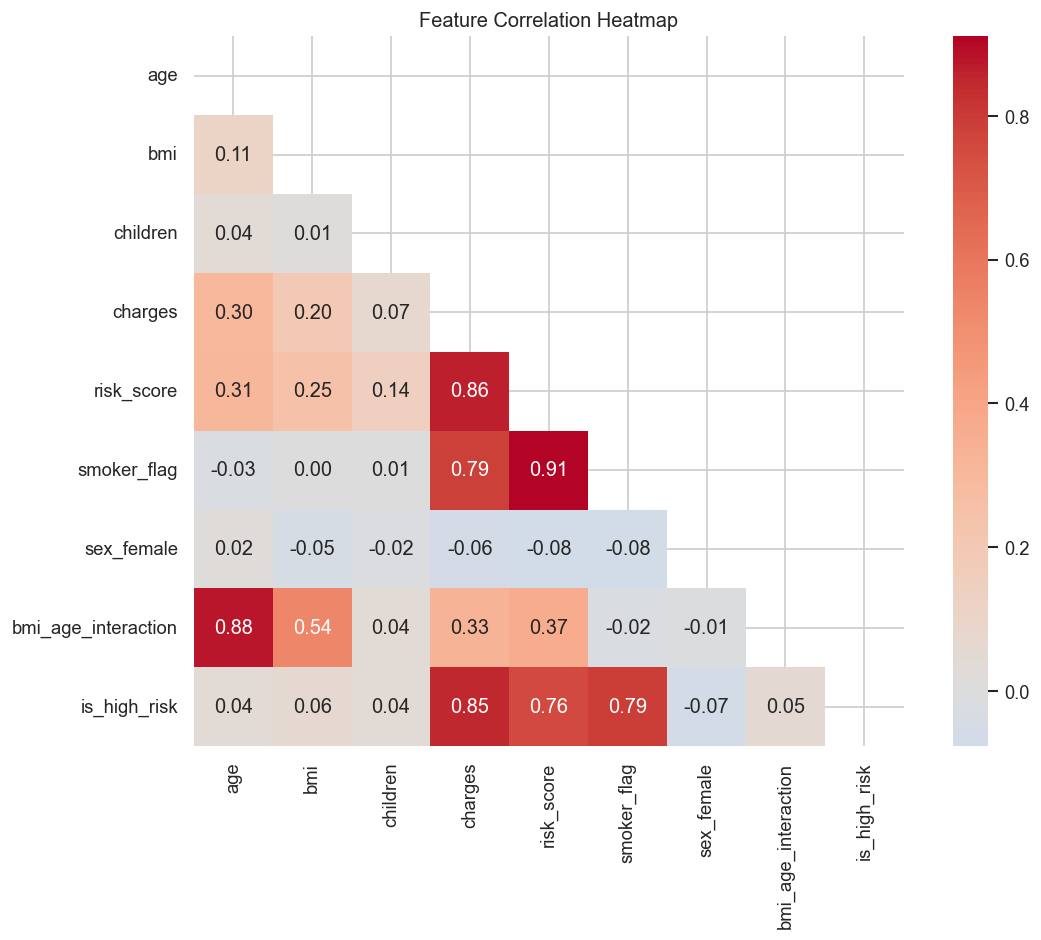

In [10]:
cols = ["age","bmi","children","charges","risk_score","smoker_flag","sex_female","bmi_age_interaction","is_high_risk"]
corr = df[cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=ax)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("../../artifacts/plots/eda_correlation_heatmap.png", bbox_inches="tight")
plt.show()

## 6. Charges vs BMI by Smoker Status

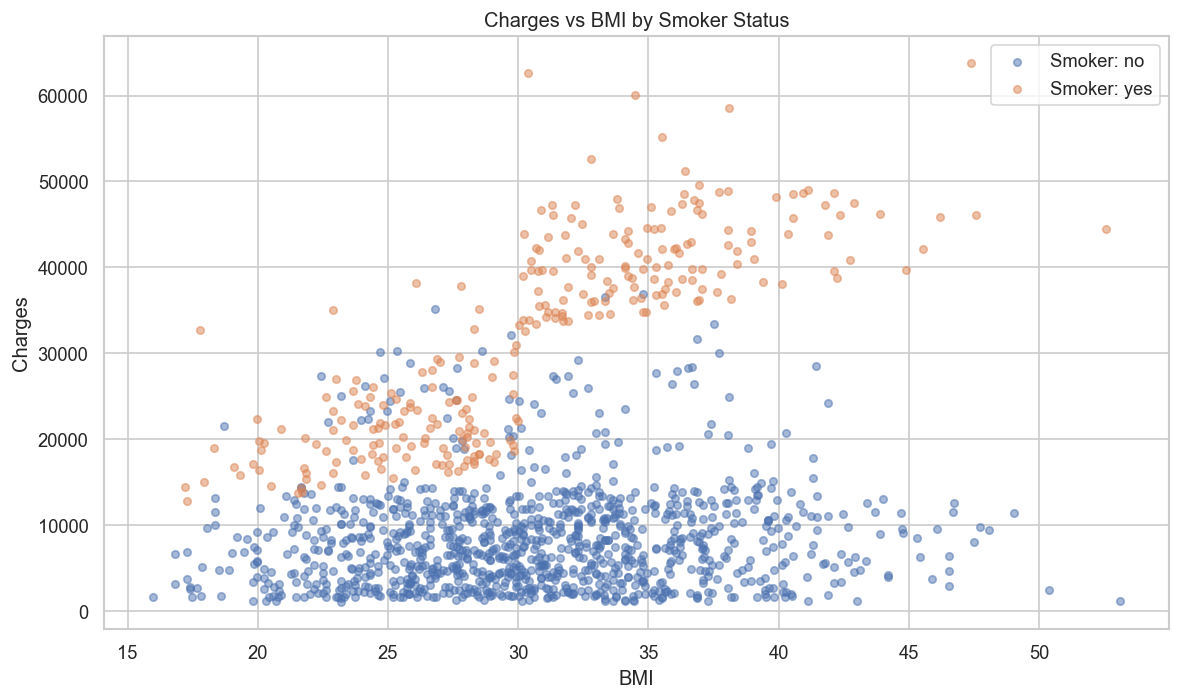

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = {"yes":"#DD8452","no":"#4C72B0"}
for s, g in df.groupby("smoker"):
    ax.scatter(g["bmi"], g["charges"], alpha=0.5, label=f"Smoker: {s}", color=colors[s], s=20)
ax.set_xlabel("BMI")
ax.set_ylabel("Charges")
ax.set_title("Charges vs BMI by Smoker Status")
ax.legend()
plt.tight_layout()
plt.savefig("../../artifacts/plots/eda_charges_bmi_smoker.png", bbox_inches="tight")
plt.show()

## Key EDA Takeaways
- Smokers are the dominant cost and risk driver
- Obese Class II/III BMI strongly predicts high risk
- Charges are right-skewed — log-transform for regression tasks
- risk_score is near-perfectly correlated with target (derived — drop in modeling)
- Children provides weak predictive signal
- Regional differences are modest; southeast slightly elevated